# Experimento: CNN Baseline vs Baseline + Augmentation

Comparacao de custo computacional (tempo de treino) e metricas (acuracia, loss)
entre o modelo baseline sem augmentation e com augmentation ativado.

Augmentation layers: RandomFlip, RandomRotation, RandomContrast

## Como usar no Colab
1. Crie um Personal Access Token no GitLab (Settings > Access Tokens > scope: read_repository)
2. Execute a celula de setup abaixo e cole o token quando solicitado
3. Execute as celulas restantes em ordem

In [1]:
# === SETUP: Clonar repo privado e instalar dependencias ===
import os
from getpass import getpass

GITLAB_HOST = "git.inteli.edu.br"
REPO_PATH = "graduacao/2026-1a/t11/g01.git"
BRANCH = "138-rodar-o-experimento-com-augmentation-ativado-coletar-tempos-de-execucao-para-comparar-custo"

if not os.path.exists("g01"):
    token = getpass("Cole seu GitLab Personal Access Token: ")
    !git clone --branch {BRANCH} https://oauth2:{token}@{GITLAB_HOST}/{REPO_PATH}
    del token  # nao manter token em memoria

os.chdir("g01")
!pip install -q pyyaml

Cole seu GitLab Personal Access Token: ··········
Cloning into 'g01'...
remote: Enumerating objects: 1608, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 1608 (delta 32), reused 0 (delta 0), pack-reused 1514 (from 1)
Receiving objects: 100% (1608/1608), 189.33 MiB | 27.15 MiB/s, done.
Resolving deltas: 100% (687/687), done.


In [2]:
# === UPLOAD: pixels_dataset.csv (necessario pois .gitignore ignora *.csv) ===
from google.colab import files
import shutil

print("Faca upload do arquivo: data/pixels_dataset.csv")
uploaded = files.upload()

# Mover para o local esperado pela config
os.makedirs("data", exist_ok=True)
for filename in uploaded:
    shutil.move(filename, "data/pixels_dataset.csv")
    print(f"✓ {filename} movido para data/pixels_dataset.csv")

Faca upload do arquivo: data/pixels_dataset.csv


Saving pixels_dataset.csv to pixels_dataset.csv
✓ pixels_dataset.csv movido para data/pixels_dataset.csv


In [3]:
import sys
sys.path.insert(0, ".")

from src.models.experiment_runner import run_multiple_experiments
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
configs = ["baseline", "baseline_augmented"]
results = run_multiple_experiments(configs)
results

✓ ExperimentRunner inicializado com config: baseline
  Configurações disponíveis: ['baseline', 'baseline_augmented', 'higher_dropout']

EXPERIMENTO: baseline

📂 Carregando dados...
✓ Dados carregados: (295, 128, 128, 9), labels: (295,)
  Classes: [0 1], distribuição: [179 116]

🏗️ Construindo modelo...
✓ Modelo compilado!

💾 Experimento: baseline_20260312_121652

🚀 Iniciando treinamento...
  Batch size: 32
  Epochs: 50
  Learning rate: 0.001
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6828 - loss: 4.2855 - val_accuracy: 0.6949 - val_loss: 1.6455
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7745 - loss: 0.8337 - val_accuracy: 0.7966 - val_loss: 1.3894
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8550 - loss: 0.8216 - val_accuracy: 0.7627 - val_loss: 0.9162
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8533 - loss: 0.6885 - val_accuracy: 0.7797 - val_loss: 0.8281
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy

✓ Treinamento concluído!
✓ Modelo salvo: /content/g01/outputs/trained_models/baseline_20260312_121652/model.h5
✓ Histórico salvo: /content/g01/outputs/trained_models/baseline_20260312_121652/history.json
✓ Novo log de experimentos criado: /content/g01/outputs/trained_models/experiments_log.csv

RESUMO DO EXPERIMENTO:
  config_name: baseline
  experiment_dir: /content/g01/outputs/trained_models/baseline_20260312_121652
  timestamp: 2026-03-12 12:28:53
  final_train_loss: 0.1899
  final_train_acc: 0.9873
  final_val_loss: 0.8464
  final_val_acc: 0.7966
  epochs_run: 50
  training_time_seconds: 720.2852
  augmentation_enabled: False
✓ ExperimentRunner inicializado com config: baseline_augmented
  Configurações disponíveis: ['baseline', 'baseline_augmented', 'higher_dropout']

EXPERIMENTO: baseline_augmented

📂 Carregando dados...
✓ Dados carregados: (295, 128, 128, 9), labels: (295,)
  Classes: [0 1], distribuição: [179 116]

🏗️ Construindo modelo...
  ✓ Data Augmentation ativado
✓ Modelo

✓ Treinamento concluído!
✓ Modelo salvo: /content/g01/outputs/trained_models/baseline_augmented_20260312_123030/model.h5
✓ Histórico salvo: /content/g01/outputs/trained_models/baseline_augmented_20260312_123030/history.json
✓ Resultado adicionado ao log: /content/g01/outputs/trained_models/experiments_log.csv

RESUMO DO EXPERIMENTO:
  config_name: baseline_augmented
  experiment_dir: /content/g01/outputs/trained_models/baseline_augmented_20260312_123030
  timestamp: 2026-03-12 12:45:40
  final_train_loss: 0.3747
  final_train_acc: 0.9407
  final_val_loss: 108.6724
  final_val_acc: 0.3390
  epochs_run: 50
  training_time_seconds: 909.6382
  augmentation_enabled: True


[{'config_name': 'baseline',
  'experiment_dir': '/content/g01/outputs/trained_models/baseline_20260312_121652',
  'timestamp': '2026-03-12 12:28:53',
  'final_train_loss': 0.18988926708698273,
  'final_train_acc': 0.9872881174087524,
  'final_val_loss': 0.8463544249534607,
  'final_val_acc': 0.7966101765632629,
  'epochs_run': 50,
  'training_time_seconds': 720.2852191925049,
  'augmentation_enabled': False},
 {'config_name': 'baseline_augmented',
  'experiment_dir': '/content/g01/outputs/trained_models/baseline_augmented_20260312_123030',
  'timestamp': '2026-03-12 12:45:40',
  'final_train_loss': 0.3746544420719147,
  'final_train_acc': 0.9406779408454895,
  'final_val_loss': 108.67235565185547,
  'final_val_acc': 0.33898305892944336,
  'epochs_run': 50,
  'training_time_seconds': 909.6382241249084,
  'augmentation_enabled': True}]

In [5]:
df = pd.DataFrame(results)
cols = [
    "config_name",
    "augmentation_enabled",
    "training_time_seconds",
    "final_train_acc",
    "final_val_acc",
    "final_train_loss",
    "final_val_loss",
    "epochs_run",
]
df_compare = df[cols].copy()
df_compare["training_time_seconds"] = df_compare["training_time_seconds"].round(2)
df_compare

,config_name,augmentation_enabled,training_time_seconds,final_train_acc,final_val_acc,final_train_loss,final_val_loss,epochs_run
0,baseline,False,720.29,0.987288,0.796610,0.189889,0.846354,50
1,baseline_augmented,True,909.64,0.940678,0.338983,0.374654,108.672356,50


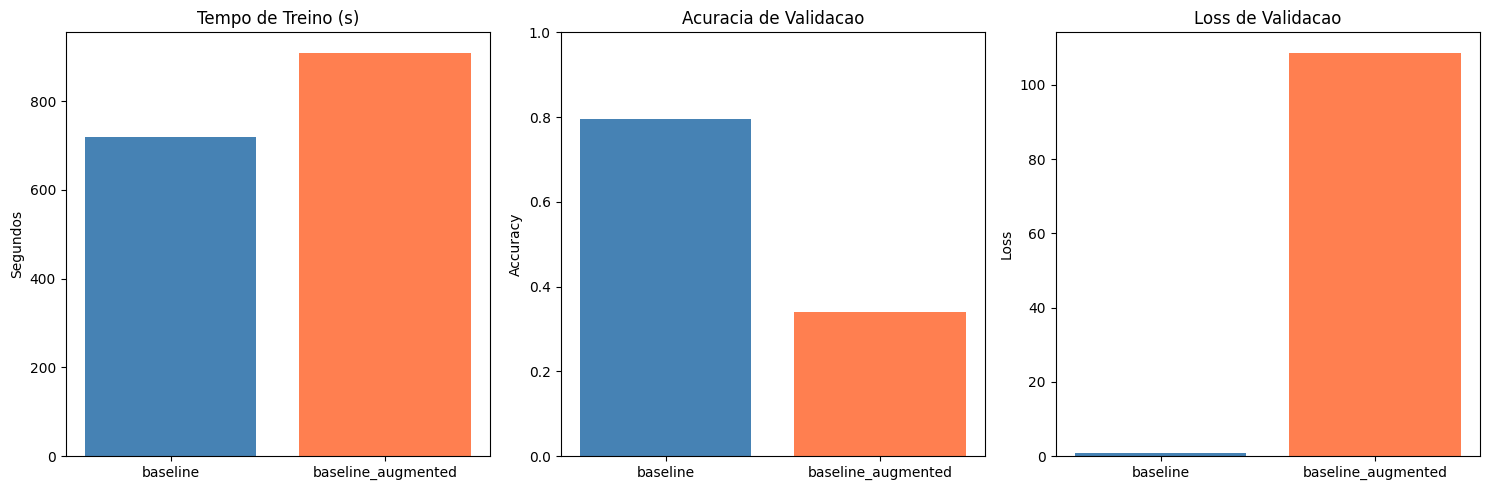


Diferenca de tempo: +26.3% (mais lento com augmentation)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Tempo de treino
axes[0].bar(df_compare["config_name"], df_compare["training_time_seconds"], color=["steelblue", "coral"])
axes[0].set_title("Tempo de Treino (s)")
axes[0].set_ylabel("Segundos")

# Acuracia de validacao
axes[1].bar(df_compare["config_name"], df_compare["final_val_acc"], color=["steelblue", "coral"])
axes[1].set_title("Acuracia de Validacao")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)

# Loss de validacao
axes[2].bar(df_compare["config_name"], df_compare["final_val_loss"], color=["steelblue", "coral"])
axes[2].set_title("Loss de Validacao")
axes[2].set_ylabel("Loss")

plt.tight_layout()
plt.savefig("outputs/augmentation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Diferenca percentual no tempo
time_baseline = df_compare.loc[df_compare["config_name"] == "baseline", "training_time_seconds"].values[0]
time_augmented = df_compare.loc[df_compare["config_name"] == "baseline_augmented", "training_time_seconds"].values[0]
pct_diff = ((time_augmented - time_baseline) / time_baseline) * 100
print(f"\nDiferenca de tempo: {pct_diff:+.1f}% ({'mais lento' if pct_diff > 0 else 'mais rapido'} com augmentation)")